## Experiment 1: Machine Learning – Regression

### Concept: Linear Regression

Linear Regression is a fundamental supervised learning algorithm used for predictive analysis. It models the relationship between a dependent variable (what we want to predict) and one or more independent variables (features) by fitting a linear equation to the observed data. The goal is to find the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the sum of squared differences between the predicted and actual values.

### Simple Example: Basic Linear Regression with Synthetic Data

This example demonstrates the core idea of linear regression using a small, artificially generated dataset. We'll create some data points that roughly follow a linear pattern, then use `scikit-learn` to find the line that best fits this data.

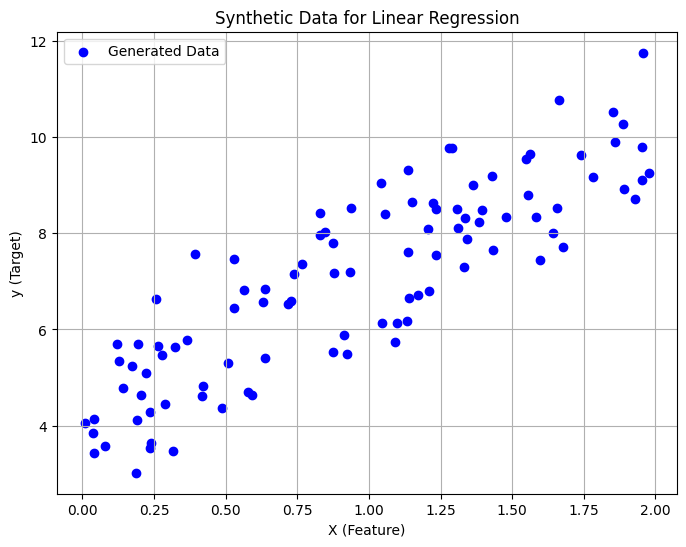

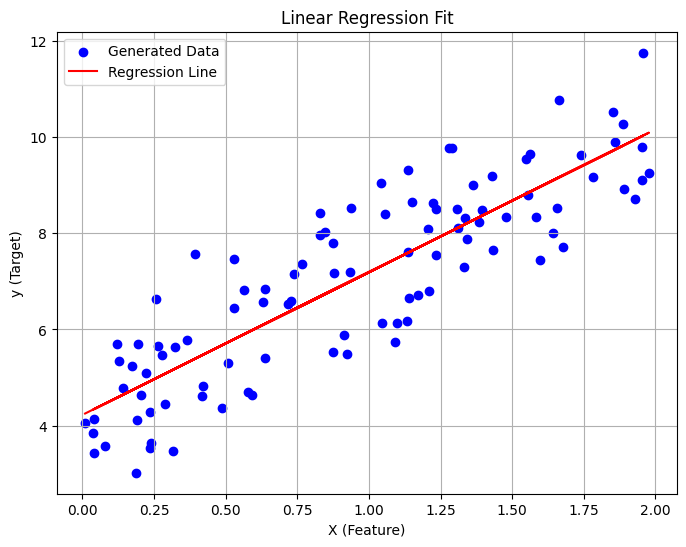

Mean Squared Error (MSE): 0.99
R-squared: 0.75
Model Coefficient (Slope): 2.97
Model Intercept: 4.22


In [1]:
# Import necessary libraries for numerical operations and plotting
import numpy as np # NumPy is used for numerical operations, especially array manipulations
import matplotlib.pyplot as plt # Matplotlib is used for creating static, interactive, and animated visualizations

# Import the Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression # This is the class for implementing Ordinary Least Squares Linear Regression

# Import mean_squared_error for evaluating the model
from sklearn.metrics import mean_squared_error, r2_score # mean_squared_error calculates the average squared difference between predictions and actual values

# 1. Generate some synthetic data
# np.random.seed(0) ensures reproducibility of the random data
np.random.seed(0)

# Generate 100 random values for our independent variable (feature) 'X'
# reshape(-1, 1) converts the 1D array into a 2D array, which is required by scikit-learn models
X = 2 * np.random.rand(100, 1) # X values between 0 and 2

# Generate our dependent variable (target) 'y' based on a linear equation y = 4 + 3X + noise
# np.random.randn(100, 1) adds some random noise to make the data more realistic
y = 4 + 3 * X + np.random.randn(100, 1) # y values with some linear trend and noise

# 2. Visualize the generated data
plt.figure(figsize=(8, 6)) # Set the size of the plot
plt.scatter(X, y, color='blue', label='Generated Data') # Plot the scatter points of X vs y
plt.title('Synthetic Data for Linear Regression') # Set the title of the plot
plt.xlabel('X (Feature)') # Label the x-axis
plt.ylabel('y (Target)') # Label the y-axis
plt.grid(True) # Add a grid to the plot for better readability
plt.legend() # Display the legend
plt.show() # Show the plot

# 3. Create a Linear Regression model instance
model = LinearRegression() # Initialize the LinearRegression object

# 4. Train the model using the generated data
# model.fit(X, y) learns the coefficients (slope) and intercept of the linear equation
# It finds the line that best minimizes the squared errors between predicted and actual y values
model.fit(X, y) # Fit the model to our X and y data

# 5. Make predictions using the trained model
# model.predict(X) uses the learned line to predict y values for the given X values
y_pred = model.predict(X) # Predict y values using the same X that we trained on

# 6. Visualize the regression line along with the data
plt.figure(figsize=(8, 6)) # Set the size of the plot
plt.scatter(X, y, color='blue', label='Generated Data') # Plot the original scatter points
plt.plot(X, y_pred, color='red', label='Regression Line') # Plot the regression line
plt.title('Linear Regression Fit') # Set the title of the plot
plt.xlabel('X (Feature)') # Label the x-axis
plt.ylabel('y (Target)') # Label the y-axis
plt.grid(True) # Add a grid
plt.legend() # Display the legend
plt.show() # Show the plot

# 7. Evaluate the model's performance
# Calculate Mean Squared Error (MSE)
# MSE measures the average of the squares of the errors—the average squared difference between the estimated values and actual value.
mse = mean_squared_error(y, y_pred) # Compare actual y with predicted y_pred
print(f'Mean Squared Error (MSE): {mse:.2f}') # Print the MSE, formatted to two decimal places

# Calculate R-squared (Coefficient of Determination)
# R-squared represents the proportion of variance in the dependent variable that can be explained by the independent variable(s).
# A value of 1 means the model perfectly predicts the target, 0 means it explains none of the variance.
r2 = r2_score(y, y_pred) # Compare actual y with predicted y_pred
print(f'R-squared: {r2:.2f}') # Print the R-squared value, formatted to two decimal places

# Print the learned coefficients (slope) and intercept
print(f'Model Coefficient (Slope): {model.coef_[0][0]:.2f}') # The slope of the regression line
print(f'Model Intercept: {model.intercept_[0]:.2f}') # The y-intercept of the regression line

### Complex Application: Predicting House Prices using California Housing Dataset

This example applies Linear Regression to a more realistic dataset: the California Housing dataset. This dataset contains various features describing houses in California districts, and the goal is to predict the median house value for each district. This will involve data loading, splitting into training/testing sets, and evaluating with multiple metrics.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Statistical summary of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Training set shape: (16512, 8)
Testing set shape: (4128, 8)

Mean Squared Error (MSE): 0.56
Root Mean Squared Error (RMSE): 0.75
Mean Absolute Error (MAE): 0.53
R-squared: 0.58


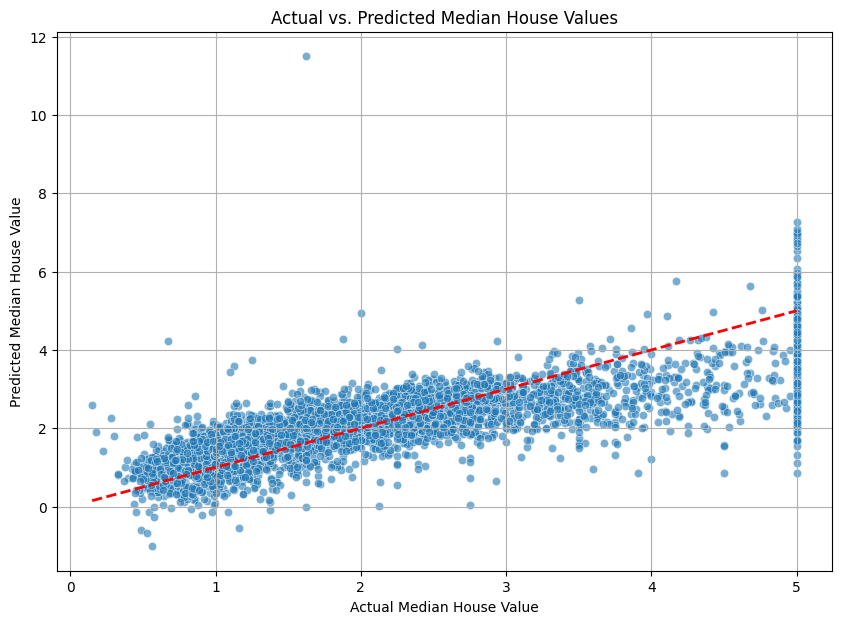

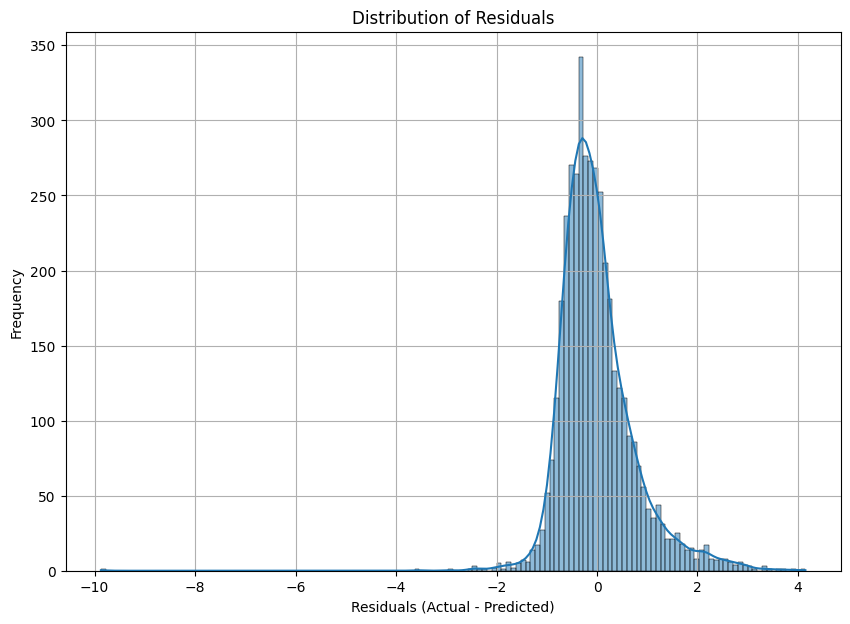


Model Coefficients (Feature Weights):
MedInc: 0.854
HouseAge: 0.123
AveRooms: -0.294
AveBedrms: 0.339
Population: -0.002
AveOccup: -0.041
Latitude: -0.897
Longitude: -0.870
Model Intercept: 2.072


In [2]:
# Import necessary libraries
import pandas as pd # Pandas is used for data manipulation and analysis, especially with DataFrames
import numpy as np # NumPy for numerical operations
import matplotlib.pyplot as plt # Matplotlib for plotting
import seaborn as sns # Seaborn for enhanced statistical data visualization

# Import datasets module from scikit-learn to load the California housing dataset
from sklearn.datasets import fetch_california_housing # Function to load the California Housing dataset

# Import tools for splitting data, linear model, and evaluation metrics
from sklearn.model_selection import train_test_split # Used to split data into training and testing sets
from sklearn.linear_model import LinearRegression # The Linear Regression model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Evaluation metrics
from sklearn.preprocessing import StandardScaler # Used for feature scaling

# 1. Load the California Housing dataset
# fetch_california_housing() returns a Bunch object, which is like a dictionary
housing = fetch_california_housing(as_frame=True) # Load the dataset; as_frame=True returns a Pandas DataFrame

# Convert to a Pandas DataFrame for easier manipulation
# housing.data contains the features, housing.target contains the target variable (median house value)
df = housing.frame # The .frame attribute directly gives the DataFrame with features and target

# 2. Explore the dataset (Basic Exploratory Data Analysis - EDA)
print('Dataset Information:') # Print a header for the info
df.info() # Displays a summary of the DataFrame, including data types and non-null values
print('\nFirst 5 rows of the dataset:') # Print a header for the head
display(df.head()) # Display the first 5 rows of the DataFrame
print('\nStatistical summary of the dataset:') # Print a header for the description
display(df.describe()) # Displays descriptive statistics for numerical columns

# 3. Define features (X) and target (y)
# All columns except 'MedHouseVal' are features
X = df.drop('MedHouseVal', axis=1) # Drop the target column to get the features DataFrame
# 'MedHouseVal' is the target variable (median house value)
y = df['MedHouseVal'] # Select the 'MedHouseVal' column as the target Series

# 4. Split the data into training and testing sets
# train_test_split shuffles and splits the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing, 80% for training
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'\nTraining set shape: {X_train.shape}') # Print the shape of the training features
print(f'Testing set shape: {X_test.shape}') # Print the shape of the testing features

# 5. Feature Scaling (Standardization)
# StandardScaler transforms features by removing the mean and scaling to unit variance
# This is important for many machine learning algorithms, including Linear Regression when regularization is used,
# and generally helps with convergence and performance.
scaler = StandardScaler() # Initialize the StandardScaler

# Fit the scaler on the training data and transform both training and testing data
# It's crucial to fit only on training data to prevent data leakage from the test set
X_train_scaled = scaler.fit_transform(X_train) # Fit scaler to X_train and transform X_train
X_test_scaled = scaler.transform(X_test) # Transform X_test using the scaler fitted on X_train

# 6. Create and train the Linear Regression model
model = LinearRegression() # Initialize the LinearRegression model

# Fit the model to the scaled training data
# The model learns the optimal coefficients for each feature to predict the target
model.fit(X_train_scaled, y_train) # Train the model on the scaled training features and target

# 7. Make predictions on the test set
# Use the trained model to predict house values for the scaled test features
y_pred = model.predict(X_test_scaled) # Generate predictions for the test set

# 8. Evaluate the model's performance
# Mean Squared Error (MSE): Average of the squared differences between actual and predicted values
mse = mean_squared_error(y_test, y_pred) # Calculate MSE
print(f'\nMean Squared Error (MSE): {mse:.2f}') # Print MSE

# Root Mean Squared Error (RMSE): The square root of MSE, often more interpretable as it's in the same units as the target
rmse = np.sqrt(mse) # Calculate RMSE
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}') # Print RMSE

# Mean Absolute Error (MAE): Average of the absolute differences between actual and predicted values
# MAE is less sensitive to outliers than MSE.
mae = mean_absolute_error(y_test, y_pred) # Calculate MAE
print(f'Mean Absolute Error (MAE): {mae:.2f}') # Print MAE

# R-squared (Coefficient of Determination): Proportion of the variance in the dependent variable predictable from the independent variables
# Ranges from 0 to 1, where 1 means perfect prediction.
r2 = r2_score(y_test, y_pred) # Calculate R-squared
print(f'R-squared: {r2:.2f}') # Print R-squared

# 9. Visualize Predictions vs. Actual values
plt.figure(figsize=(10, 7)) # Set the figure size
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6) # Create a scatter plot of actual vs. predicted values
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Plot a perfect prediction line (y=x)
plt.xlabel('Actual Median House Value') # Label the x-axis
plt.ylabel('Predicted Median House Value') # Label the y-axis
plt.title('Actual vs. Predicted Median House Values') # Set the plot title
plt.grid(True) # Add a grid
plt.show() # Display the plot

# 10. Visualize Residuals (Error Distribution)
# Residuals are the differences between the actual and predicted values (y_test - y_pred)
residuals = y_test - y_pred # Calculate residuals

plt.figure(figsize=(10, 7)) # Set the figure size
sns.histplot(residuals, kde=True) # Plot a histogram of residuals with a Kernel Density Estimate
plt.title('Distribution of Residuals') # Set the plot title
plt.xlabel('Residuals (Actual - Predicted)') # Label the x-axis
plt.ylabel('Frequency') # Label the y-axis
plt.grid(True) # Add a grid
plt.show() # Display the plot

print('\nModel Coefficients (Feature Weights):') # Print a header for coefficients
# Pair feature names with their learned coefficients
# These coefficients indicate the importance and direction of influence of each feature on the target variable
for feature, coef in zip(X.columns, model.coef_):
    print(f'{feature}: {coef:.3f}') # Print each feature and its corresponding coefficient

print(f'Model Intercept: {model.intercept_:.3f}') # Print the intercept of the model